In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

california = fetch_california_housing(as_frame=True)
df = california.frame

X = df[['AveRooms']].values
y = df['MedHouseVal'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Dataset Loaded successfully.")
print(f"Feature Matrix Shape (X): {X.shape}")
print(f"Target Vector Shape (y): {y.shape}\n")


scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

m = len(X_train_scaled)

X_b = np.c_[np.ones((m, 1)), X_train_scaled]

Dataset Loaded successfully.
Feature Matrix Shape (X): (20640, 1)
Target Vector Shape (y): (20640, 1)

Training samples: 16512
Testing samples: 4128


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))


X_train_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

theta_normal_scaled = np.linalg.inv(X_train_b.T.dot(X_train_b)).dot(X_train_b.T).dot(y_train_scaled)


y_pred_normal_scaled = X_test_b.dot(theta_normal_scaled)

y_pred_normal = scaler_y.inverse_transform(y_pred_normal_scaled)
def compute_cost(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost

def gradient_descent(X, y, theta, learning_rate, iterations):
    m = len(y)
    cost_history = []

    for i in range(iterations):
        gradients = (1 / m) * X.T.dot(X.dot(theta) - y)
        theta = theta - learning_rate * gradients
        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history


learning_rate = 0.01
iterations = 1500
initial_theta = np.zeros((X_train_b.shape[1], 1))
theta_gd_scaled, cost_history = gradient_descent(
    X_train_b,
    y_train_scaled,
    initial_theta,
    learning_rate,
    iterations
)

y_pred_gd_scaled = X_test_b.dot(theta_gd_scaled)


y_pred_gd = scaler_y.inverse_transform(y_pred_gd_scaled)
from sklearn.metrics import mean_squared_error, r2_score

print("Normal Equation")
print("MSE:", mean_squared_error(y_test, y_pred_normal))
print("R² Score:", r2_score(y_test, y_pred_normal))

print("\nGradient Descent")
print("MSE:", mean_squared_error(y_test, y_pred_gd))
print("R² Score:", r2_score(y_test, y_pred_gd))

Normal Equation
MSE: 1.2923314440807299
R² Score: 0.013795337532284901

Gradient Descent
MSE: 1.2923314362391949
R² Score: 0.01379534351632139


In [11]:

mse_normal = mean_squared_error(y_test, y_pred_normal)
r2_normal = r2_score(y_test, y_pred_normal)

mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print("----- MODEL EVALUATION RESULTS -----")

print("Normal Equation:")
print(f"  - Mean Squared Error (MSE): {mse_normal:.4f}")
print(f"  - R-squared (R²):           {r2_normal:.4f}\n")

print("Gradient Descent:")
print(f"  - Mean Squared Error (MSE): {mse_gd:.4f}")
print(f"  - R-squared (R²):           {r2_gd:.4f}\n")

print("Final Weights (Scaled)")
print(f"Normal Equation : Intercept = {theta_normal_scaled[0][0]:.4f}, Slope = {theta_normal_scaled[1][0]:.4f}")
print(f"Gradient Descent: Intercept = {theta_gd_scaled[0][0]:.4f}, Slope = {theta_gd_scaled[1][0]:.4f}")

----- MODEL EVALUATION RESULTS -----
Normal Equation:
  - Mean Squared Error (MSE): 1.2923
  - R-squared (R²):           0.0138

Gradient Descent:
  - Mean Squared Error (MSE): 1.2923
  - R-squared (R²):           0.0138

Final Weights (Scaled)
Normal Equation : Intercept = 0.0000, Slope = 0.1585
Gradient Descent: Intercept = 0.0000, Slope = 0.1585


In [11]:

mse_normal = mean_squared_error(y_test, y_pred_normal)
r2_normal = r2_score(y_test, y_pred_normal)

mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print("----- MODEL EVALUATION RESULTS -----")

print("Normal Equation:")
print(f"  - Mean Squared Error (MSE): {mse_normal:.4f}")
print(f"  - R-squared (R²):           {r2_normal:.4f}\n")

print("Gradient Descent:")
print(f"  - Mean Squared Error (MSE): {mse_gd:.4f}")
print(f"  - R-squared (R²):           {r2_gd:.4f}\n")

print("Final Weights (Scaled)")
print(f"Normal Equation : Intercept = {theta_normal_scaled[0][0]:.4f}, Slope = {theta_normal_scaled[1][0]:.4f}")
print(f"Gradient Descent: Intercept = {theta_gd_scaled[0][0]:.4f}, Slope = {theta_gd_scaled[1][0]:.4f}")

----- MODEL EVALUATION RESULTS -----
Normal Equation:
  - Mean Squared Error (MSE): 1.2923
  - R-squared (R²):           0.0138

Gradient Descent:
  - Mean Squared Error (MSE): 1.2923
  - R-squared (R²):           0.0138

Final Weights (Scaled)
Normal Equation : Intercept = 0.0000, Slope = 0.1585
Gradient Descent: Intercept = 0.0000, Slope = 0.1585


In [ ]:
# Sort the test data for a smooth regression line
sort_axis = np.argsort(X_test.flatten())
X_sorted = X_test[sort_axis]
y_pred_gd_sorted = y_pred_gd[sort_axis]

# Plot actual test data and regression line
plt.figure(figsize=(10, 6))

plt.scatter(
    X_test[:1000],
    y_test[:1000],
    color='gray',
    alpha=0.5,
    label='Actual Test Data (Subset)'
)

plt.plot(
    X_sorted,
    y_pred_gd_sorted,
    color='crimson',
    linewidth=3,
    label='Fitted Regression Line'
)

plt.title('Linear Regression: AveRooms vs Median House Value (Test Set)', fontsize=14)
plt.xlabel('Average Rooms Per Dwelling (AveRooms)', fontsize=12)
plt.ylabel('Median House Value (in $100,000s)', fontsize=12)

plt.xlim(0, 15)
plt.ylim(0, 5.5)

plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [3]:
df.info

<bound method DataFrame.info of        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

california = fetch_california_housing(as_frame=True)
df = california.frame


X = df[['AveRooms']].values
y = df['MedHouseVal'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Dataset Loaded successfully.")
print(f"Feature Matrix Shape (X): {X.shape}")
print(f"Target Vector Shape (y): {y.shape}\n")


scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

m = len(X_train_scaled)
X_b = np.c_[np.ones((m, 1)), X_train_scaled]

Dataset Loaded successfully.
Feature Matrix Shape (X): (20640, 1)
Target Vector Shape (y): (20640, 1)



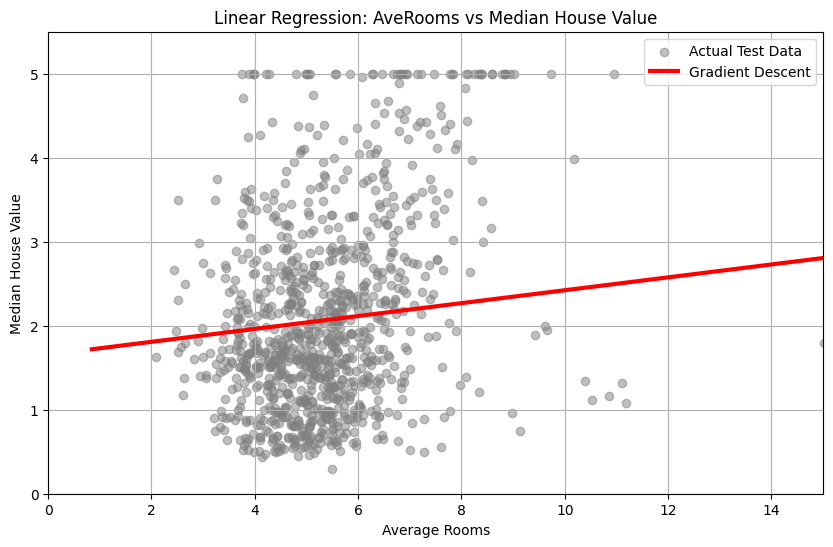

In [14]:
sort_axis = np.argsort(X_test.flatten())
X_sorted = X_test[sort_axis]
y_pred_gd_sorted = y_pred_gd[sort_axis]

plt.figure(figsize=(10,6))

plt.scatter(
    X_test[:1000],
    y_test[:1000],
    color='gray',
    alpha=0.5,
    label='Actual Test Data'
)

plt.plot(
    X_sorted,
    y_pred_gd_sorted,
    color='red',
    linewidth=3,
    label='Gradient Descent'
)

plt.title("Linear Regression: AveRooms vs Median House Value")
plt.xlabel("Average Rooms")
plt.ylabel("Median House Value")

plt.xlim(0, 15)
plt.ylim(0, 5.5)

plt.legend()
plt.grid(True)

plt.show()

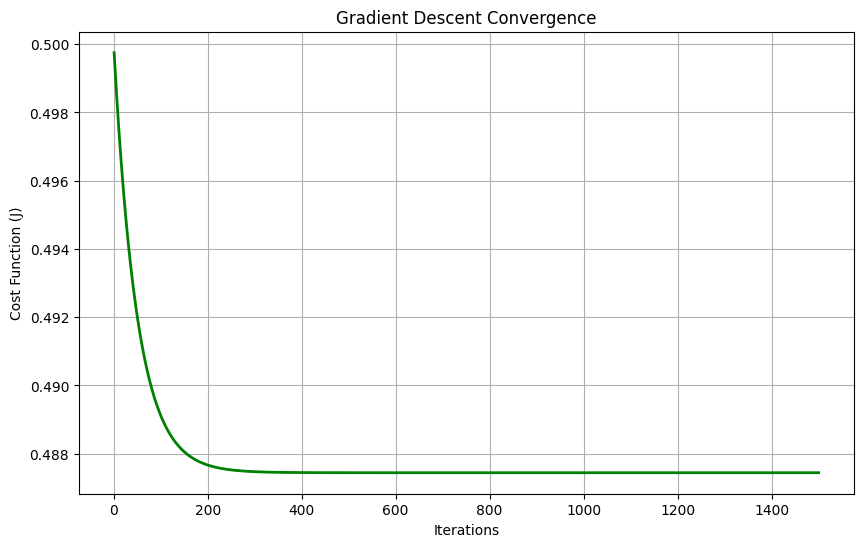

In [16]:
plt.figure(figsize=(10,6))

plt.plot(
    range(1, len(cost_history)+1),
    cost_history,
    color='green',
    linewidth=2
)

plt.title("Gradient Descent Convergence")
plt.xlabel("Iterations")
plt.ylabel("Cost Function (J)")
plt.grid(True)

plt.show()

In [15]:

theta_normal_scaled = np.linalg.inv(X_train_b.T.dot(X_train_b)).dot(X_train_b.T).dot(y_train_scaled)


y_pred_normal_scaled = X_test_b.dot(theta_normal_scaled)


y_pred_normal = scaler_y.inverse_transform(y_pred_normal_scaled)

In [19]:

theta_gd_scaled, cost_history = gradient_descent(
    X_train_b,
    y_train_scaled,
    initial_theta,
    learning_rate,
    iterations
)


y_pred_gd_scaled = X_test_b.dot(theta_gd_scaled)


y_pred_gd = scaler_y.inverse_transform(y_pred_gd_scaled)